In [2]:
import matplotlib.pyplot as plt
import numpy as np

Saved aggregated PR curve data to Signal_processing/final/results/compare_versions_ws100/precision_recall_v2_mean.csv


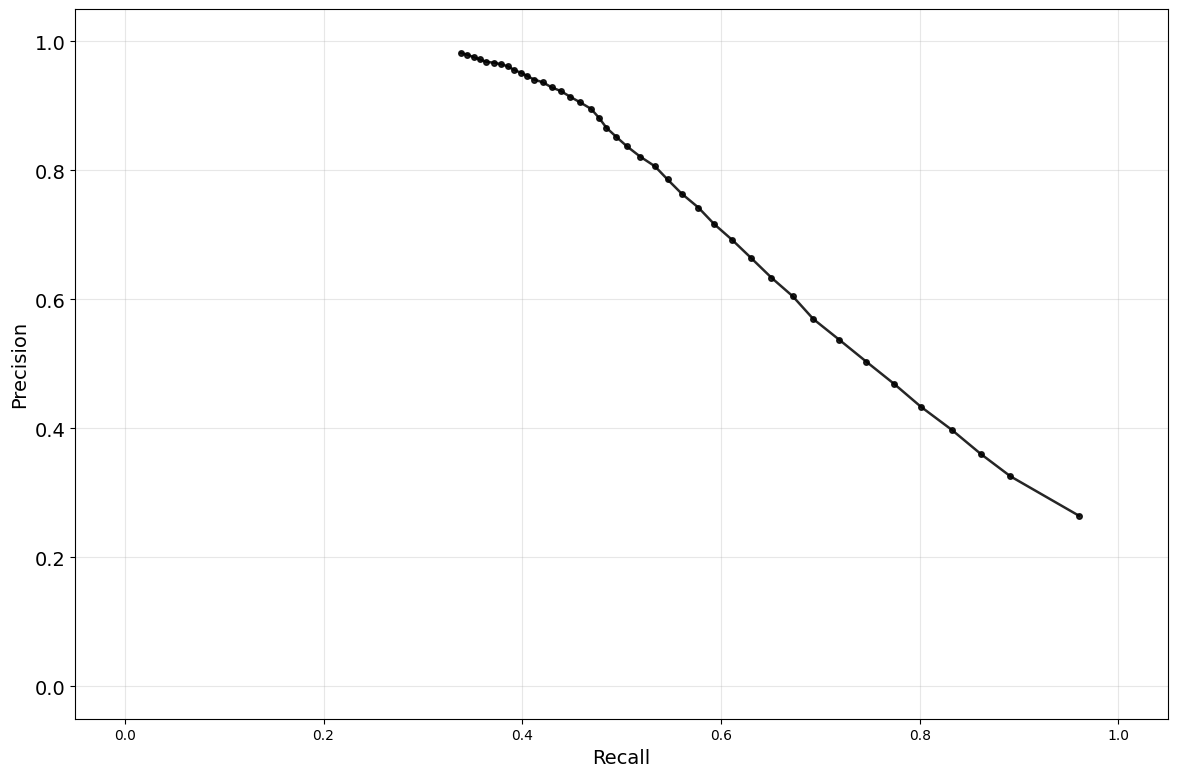

Saved PR curve plot to Signal_processing/final/results/compare_versions_ws100/precision_recall_v2_mean.png


,threshold,precision_mean,recall_mean,n_datasets
0,40.0,0.981867,0.338157,10
1,39.0,0.979032,0.344862,10
2,38.0,0.975390,0.351235,10
3,37.0,0.971812,0.357497,10
4,36.0,0.968212,0.363565,10


In [3]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Adjust this if your notebook is in a different location
project_root = os.path.abspath("../..")
if project_root not in sys.path:
	sys.path.append(project_root)

from Utils.plot_config import COLORS, setup_plot_style


setup_plot_style()


RESULTS_FILE = "Signal_processing/final/results/compare_versions_ws100/all_results.csv"
OUTPUT_FOLDER = "Signal_processing/final/results/compare_versions_ws100"


def aggregate_precision_recall_curve(results_df):
	"""Aggregate mean precision and recall over the 10 datasets for v2."""
	v2_df = results_df[results_df["method"] == "v2"].copy()
	if v2_df.empty:
		raise ValueError("No rows found for method 'v2'")

	agg_df = (
		v2_df.groupby("threshold")
		.agg(
			precision_mean=("precision", "mean"),
			recall_mean=("recall", "mean"),
			n_datasets=("dataset_id", "nunique"),
		)
		.reset_index()
		.sort_values("recall_mean")
		.reset_index(drop=True)
	)

	return agg_df


def plot_precision_recall_curve(agg_df, output_path=None):
	"""Plot mean precision-recall curve for v2."""
	fig, ax = plt.subplots(figsize=(12, 8))

	ax.plot(
		agg_df["recall_mean"].values,
		agg_df["precision_mean"].values,
		"o-",
		linewidth=1.8,
		markersize=4,
		alpha=0.85,
		color=COLORS["black"],
		label="version 3",
	)

	ax.set_xlabel("Recall")
	ax.set_ylabel("Precision")
	ax.grid(True, alpha=0.3)
	ax.set_xlim(-0.05, 1.05)
	ax.set_ylim(-0.05, 1.05)

	plt.tight_layout()

	if output_path is not None:
		plt.savefig(output_path, dpi=300, bbox_inches="tight")

	plt.show()


os.makedirs(OUTPUT_FOLDER, exist_ok=True)

results_df = pd.read_csv(RESULTS_FILE)
agg_df = aggregate_precision_recall_curve(results_df)

agg_csv = os.path.join(OUTPUT_FOLDER, "precision_recall_v2_mean.csv")
agg_df.to_csv(agg_csv, index=False)
print(f"Saved aggregated PR curve data to {agg_csv}")

plot_path = os.path.join(OUTPUT_FOLDER, "precision_recall_v2_mean.png")
plot_precision_recall_curve(agg_df, plot_path)
print(f"Saved PR curve plot to {plot_path}")

agg_df.head()

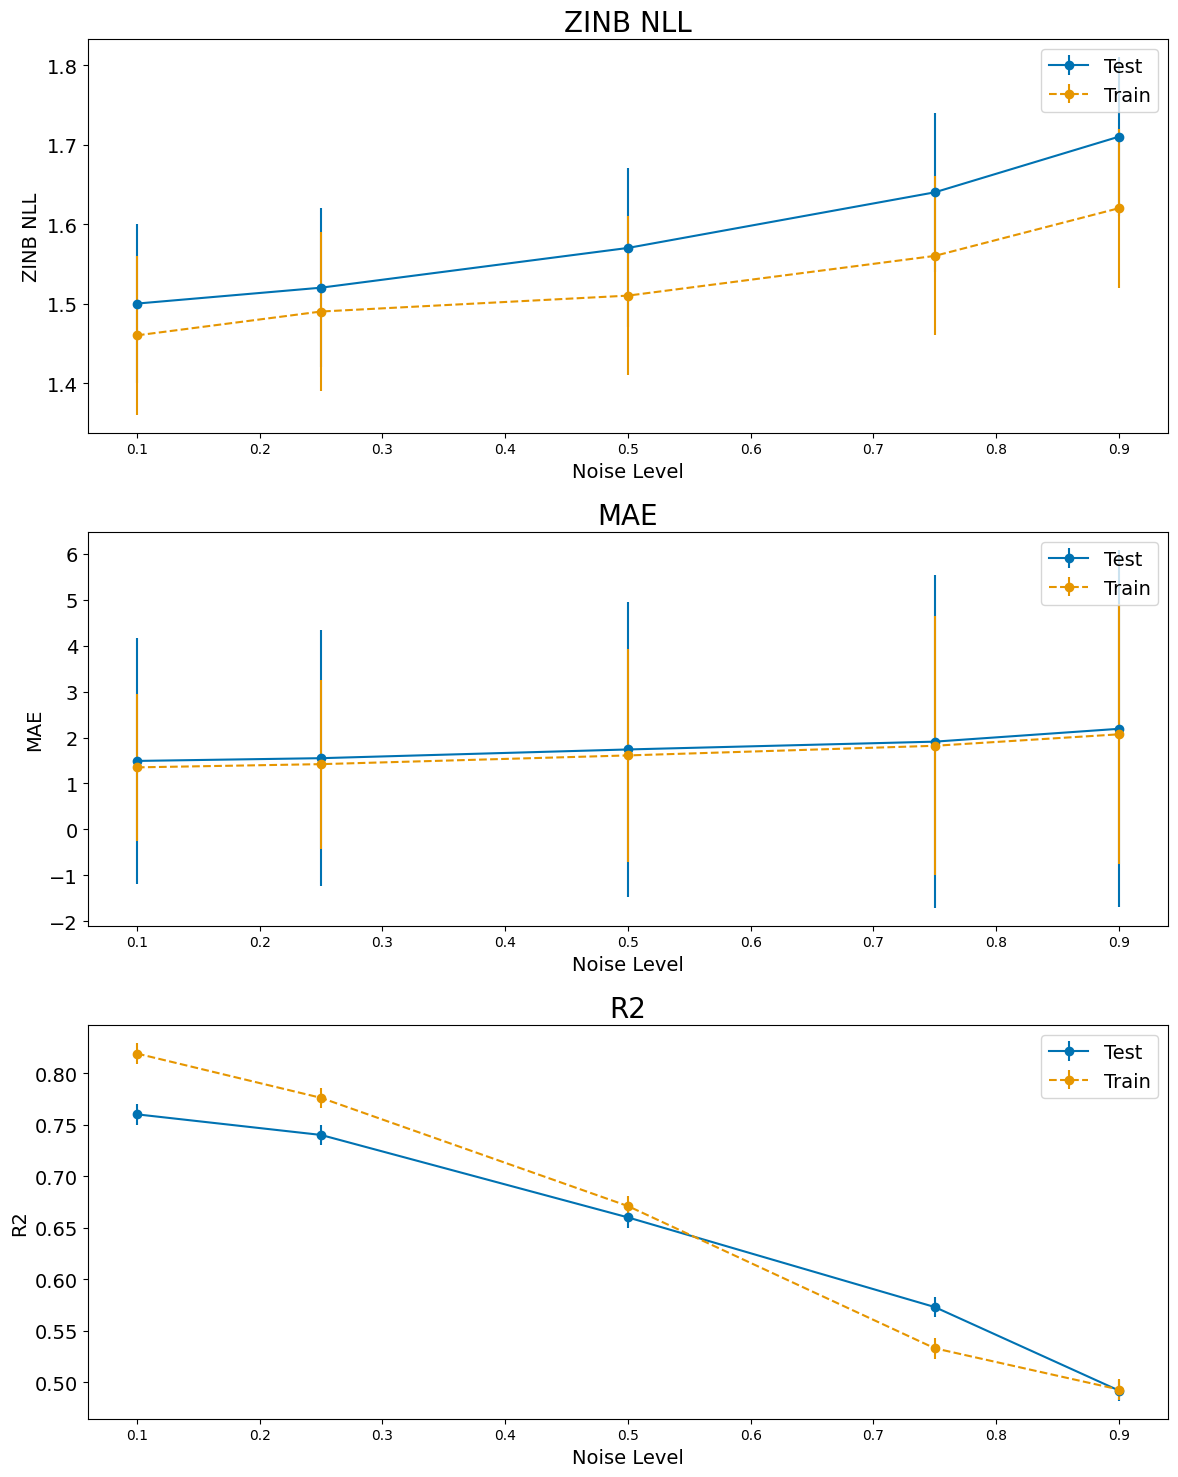

In [4]:
from Utils.plot_config import setup_plot_style, COLORS

setup_plot_style()

test_color = COLORS["blue"]
train_color = COLORS["orange"]

noise_levels = [0.10, 0.25, 0.5, 0.75, 0.9]
# Metrics different noise levels test
ZINB_NLL = [1.50, 1.52, 1.57, 1.64, 1.71]
MAE = [1.49, 1.55, 1.74, 1.91, 2.19]
MAE_SD = [2.68, 2.79, 3.21, 3.62, 3.89]
R2 = [0.760, 0.740, 0.660, 0.573, 0.492]
# pi_zero = [0, 0, 0, 0, 0]
# pi_non_zero = [0, 0, 0, 0, 0]
# pi_zero_SD = [0, 0, 0, 0, 0]
# pi_non_zero_SD = [0, 0.0001, 0.0001, 0.001, 0]

# Metrics different noise levels train
ZINB_NLL_train = [1.46, 1.49, 1.51, 1.56, 1.62]
MAE_train = [1.35, 1.42, 1.61, 1.82, 2.07]
MAE_SD_train = [1.60, 1.84, 2.32, 2.82, 2.83]
R2_train = [0.819, 0.776, 0.671, 0.533, 0.493]
# pi_zero_train = [0, 0, 0, 0, 0]
# pi_non_zero_train = [0, 0, 0, 0, 0]
# pi_zero_SD_train = [0.0016, 0.0016, 0.0013, 0.0004, 0.0001]
# pi_non_zero_SD_train = [0, 0, 0.0001, 0.0001, 0]

# Plot 3 subplots each for each metric with noise level on x-axis and metric value on y-axis, with error bars for SD where applicable.
# Use black line, and dashed line for training metrics. Add legend for train and test. Add title for each subplot with metric name.
fig, axs = plt.subplots(3, 1, figsize=(12, 15))
axs[0].errorbar(noise_levels, ZINB_NLL, yerr=0.1, fmt='-o', label='Test', color=test_color)
axs[0].errorbar(noise_levels, ZINB_NLL_train, yerr=0.1, fmt='--o', label='Train', color=train_color)
axs[0].set_title('ZINB NLL')
axs[0].set_xlabel('Noise Level')
axs[0].set_ylabel('ZINB NLL')
axs[0].legend()
axs[1].errorbar(noise_levels, MAE, yerr=MAE_SD, fmt='-o', label='Test', color=test_color)
axs[1].errorbar(noise_levels, MAE_train, yerr=MAE_SD_train, fmt='--o', label='Train', color=train_color)
axs[1].set_title('MAE')
axs[1].set_xlabel('Noise Level')
axs[1].set_ylabel('MAE')
axs[1].legend()
axs[2].errorbar(noise_levels, R2, yerr=0.01, fmt='-o', label='Test', color=test_color)
axs[2].errorbar(noise_levels, R2_train, yerr=0.01, fmt='--o', label='Train', color=train_color)
axs[2].set_title('R2')
axs[2].set_xlabel('Noise Level')
axs[2].set_ylabel('R2')
axs[2].legend()
plt.tight_layout()
plt.show()

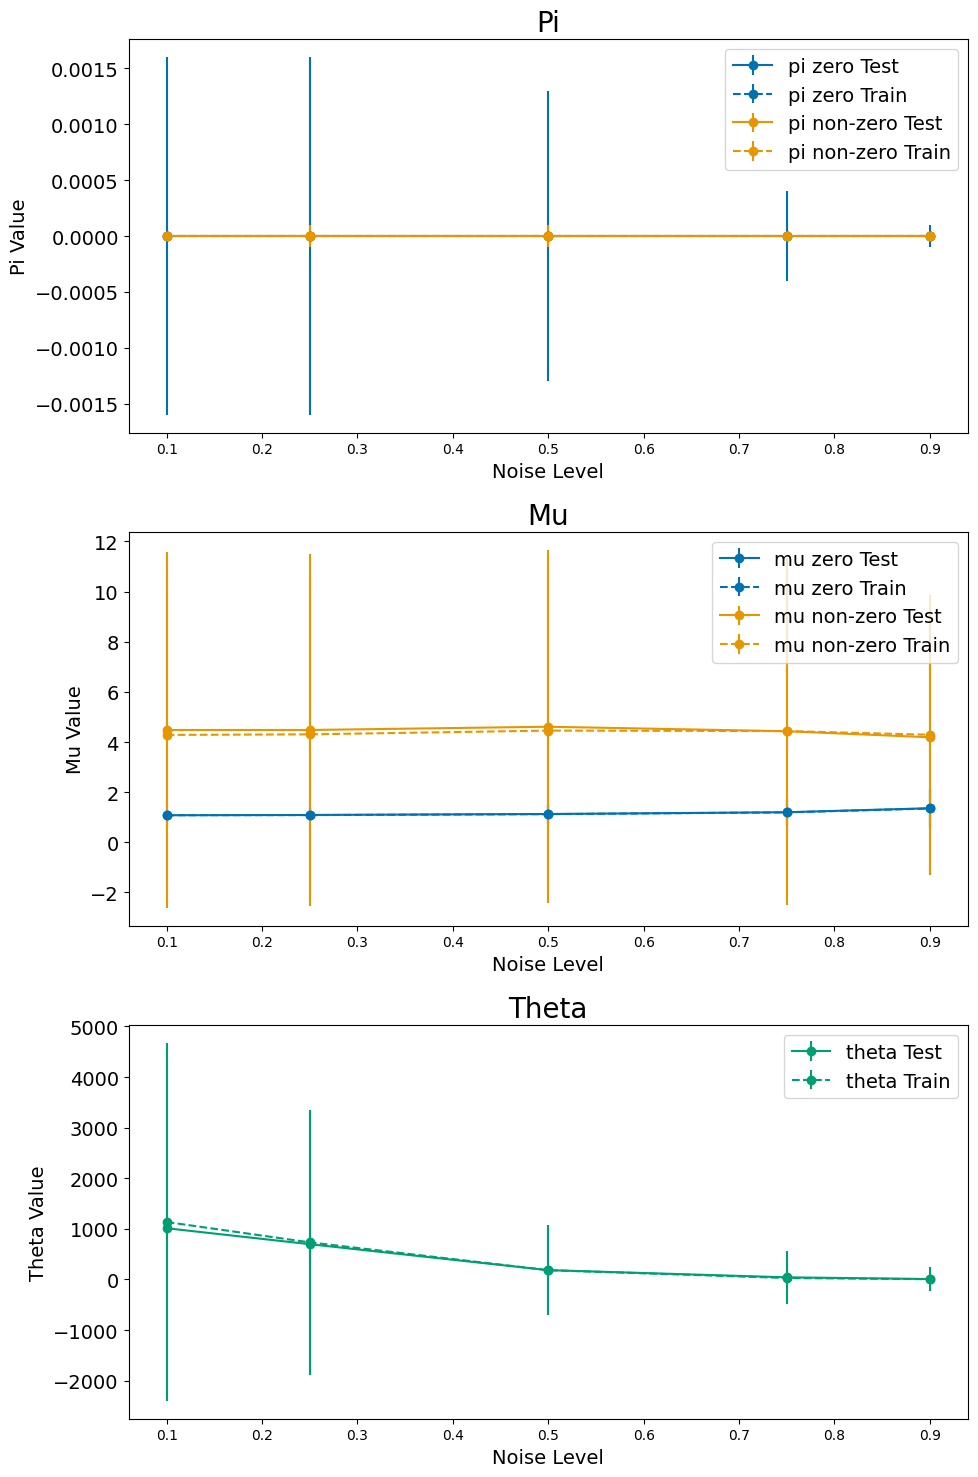

In [5]:
from Utils.plot_config import setup_plot_style, COLORS

setup_plot_style()

noise_levels = [0.10, 0.25, 0.5, 0.75, 0.9]
# pi, mu and theta for test set diffrent noise levels
pi_zero = [0, 0, 0, 0, 0]
pi_non_zero = [0, 0, 0, 0, 0]
pi_zero_SD = [0, 0, 0, 0, 0]
pi_non_zero_SD = [0, 0.0001, 0.0001, 0, 0]  
mu_zero = [1.08, 1.092, 1.13, 1.20, 1.36]
mu_non_zero = [4.48, 4.48, 4.61, 4.43, 4.19]
mu_zero_SD = [0.254, 0.286, 0.391, 0.529, 0.748]
mu_non_zero_SD = [7.092, 7.023, 7.039, 6.916, 5.47]
theta = [1012, 697, 184, 42, 8.24]
theta_sd = [3315, 2567, 888, 526, 228.5]   
# pi, mu and theta for train set different noise levels
pi_zero_train = [0, 0, 0, 0, 0]
pi_non_zero_train = [0, 0, 0, 0, 0]
pi_zero_SD_train = [0.0016, 0.0016, 0.0013, 0.0004, 0.0001]
pi_non_zero_SD_train = [0, 0, 0.0001, 0, 0]
mu_zero_train = [1.082, 1.086, 1.124, 1.195, 1.350]
mu_non_zero_train = [4.284, 4.306, 4.456, 4.437, 4.29]
mu_zero_SD_train = [0.258, 0.281, 0.384, 0.551, 0.796]
mu_non_zero_SD_train = [6.213, 6.285, 6.495, 6.524, 5.579]
theta_train = [1135, 733, 183, 28.51, 5.135]
theta_sd_train = [3534, 2618, 825, 269, 83.5]

# Plot pi, mu and theta for test and train set with noise level on x-axis and value on y-axis, with error bars for SD where applicable. Use different colors for zero and non-zero and dashed line for train and solid line for test. the train and test set should have the same color. 
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Pick consistent colors per quantity
c_pi0, c_pi1 = COLORS["blue"], COLORS["orange"]
c_mu0, c_mu1 = COLORS["blue"], COLORS["orange"]
c_th = COLORS["green"]

# --- Pi ---
axs[0].errorbar(noise_levels, pi_zero,         yerr=pi_zero_SD,
                marker='o', linestyle='-',  color=c_pi0, label='pi zero Test')
axs[0].errorbar(noise_levels, pi_zero_train,   yerr=pi_zero_SD_train,
                marker='o', linestyle='--', color=c_pi0, label='pi zero Train')

axs[0].errorbar(noise_levels, pi_non_zero,     yerr=pi_non_zero_SD,
                marker='o', linestyle='-',  color=c_pi1, label='pi non-zero Test')
axs[0].errorbar(noise_levels, pi_non_zero_train,yerr=pi_non_zero_SD_train,
                marker='o', linestyle='--', color=c_pi1, label='pi non-zero Train')

axs[0].set_title('Pi')
axs[0].set_xlabel('Noise Level')
axs[0].set_ylabel('Pi Value')
axs[0].legend()

# --- Mu ---
axs[1].errorbar(noise_levels, mu_zero,         yerr=mu_zero_SD,
                marker='o', linestyle='-',  color=c_mu0, label='mu zero Test')
axs[1].errorbar(noise_levels, mu_zero_train,   yerr=mu_zero_SD_train,
                marker='o', linestyle='--', color=c_mu0, label='mu zero Train')

axs[1].errorbar(noise_levels, mu_non_zero,     yerr=mu_non_zero_SD,
                marker='o', linestyle='-',  color=c_mu1, label='mu non-zero Test')
axs[1].errorbar(noise_levels, mu_non_zero_train,yerr=mu_non_zero_SD_train,
                marker='o', linestyle='--', color=c_mu1, label='mu non-zero Train')

axs[1].set_title('Mu')
axs[1].set_xlabel('Noise Level')
axs[1].set_ylabel('Mu Value')
axs[1].legend()

# --- Theta ---
axs[2].errorbar(noise_levels, theta,       yerr=theta_sd,
                marker='o', linestyle='-',  color=c_th, label='theta Test')
axs[2].errorbar(noise_levels, theta_train, yerr=theta_sd_train,
                marker='o', linestyle='--', color=c_th, label='theta Train')

axs[2].set_title('Theta')
axs[2].set_xlabel('Noise Level')
axs[2].set_ylabel('Theta Value')
axs[2].legend()

plt.tight_layout()
plt.show()


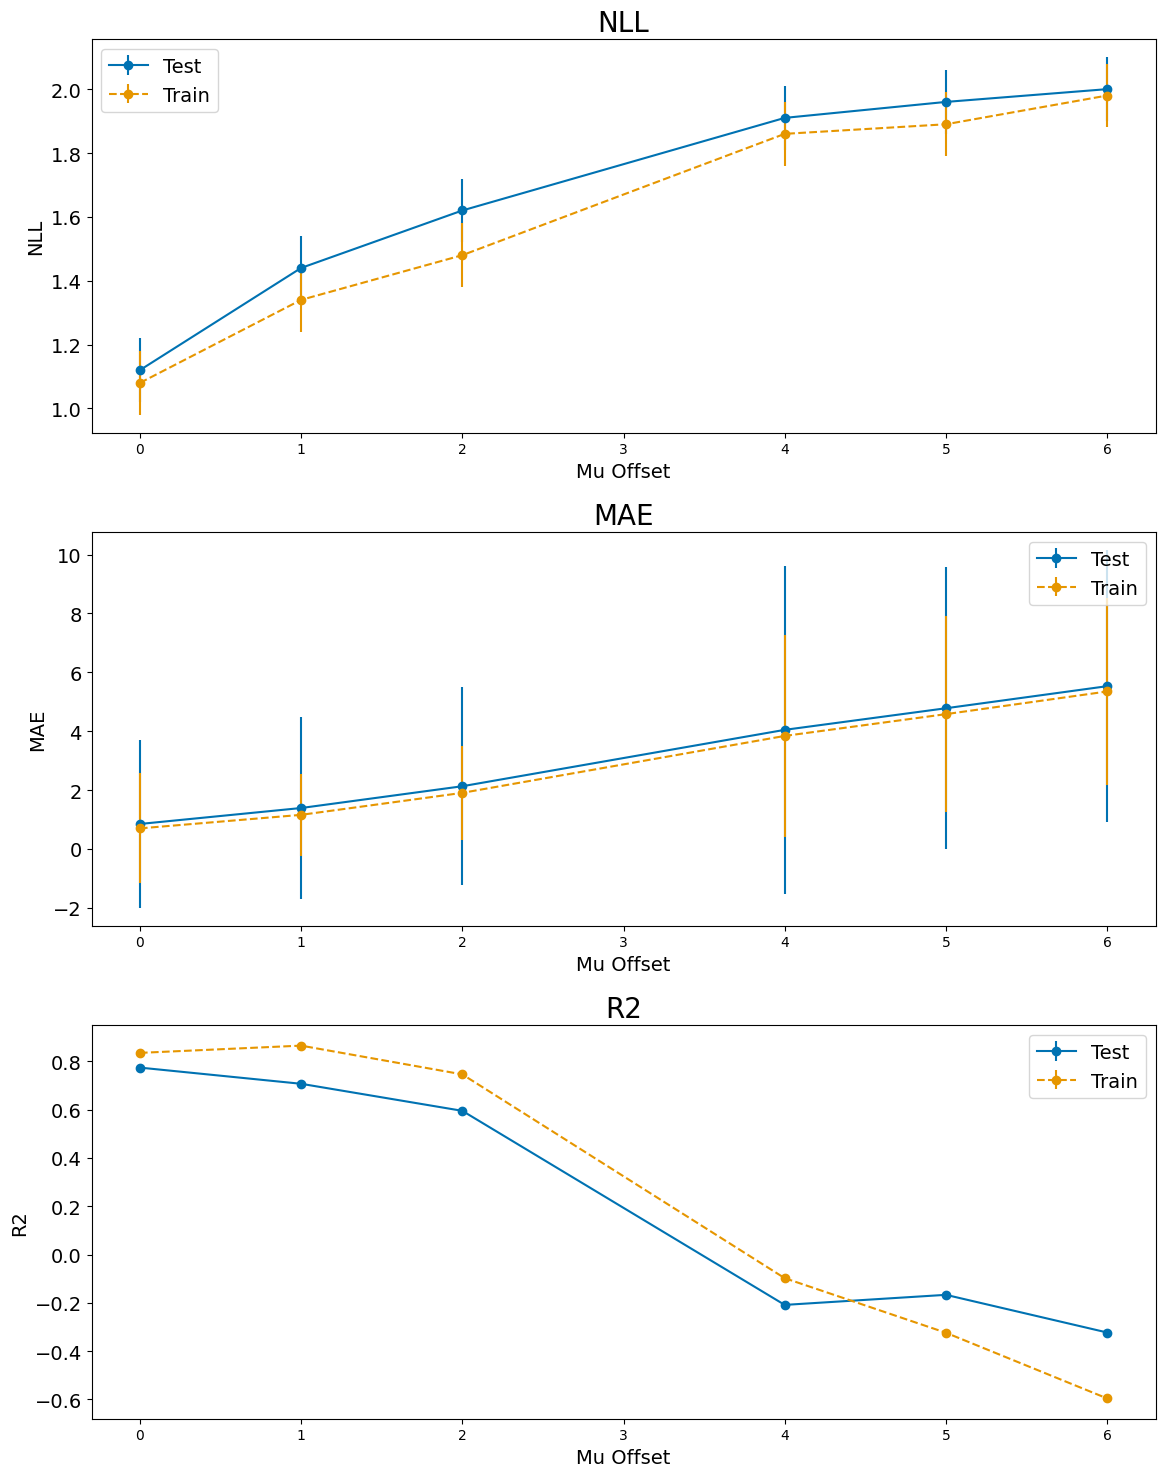

In [6]:
from Utils.plot_config import setup_plot_style, COLORS

setup_plot_style()

test_color = COLORS["blue"]
train_color = COLORS["orange"]

mu_offset = [0, 1, 2, 3, 4, 5, 6]
# Metrics test set different mu_offset
nll = [1.12, 1.44, 1.62, 1.880, 1.910, 1.96, 2.00]
mae = [0.848, 1.39, 2.13, 18.94, 4.046, 4.78, 5.53]
mae_sd = [2.85, 3.10, 3.37, 31266, 5.567, 4.79, 4.62]
r2 = [0.774, 0.707, 0.595, -24943720, -0.2087, -0.167, -0.323 ]
# Metrics train set different mu_offset
nll_train = [1.08, 1.34, 1.48, 1.79, 1.86, 1.89, 1.98]
mae_train = [0.698, 1.158, 1.905, 3.15, 3.84, 4.58, 5.35]
mae_sd_train = [1.87, 1.398, 1.59, 3.65, 3.44, 3.32, 3.18]
r2_train = [0.835, 0.865, 0.746, 0.0402, -0.0980, -0.324, -0.596]

mu_offset = [0, 1, 2, 4, 5, 6]
# Metrics test set different mu_offset
nll = [1.12, 1.44, 1.62, 1.910, 1.96, 2.00]
mae = [0.848, 1.39, 2.13, 4.046, 4.78, 5.53]
mae_sd = [2.85, 3.10, 3.37, 5.567, 4.79, 4.62]
r2 = [0.774, 0.707, 0.595,  -0.2087, -0.167, -0.323 ]
# Metrics train set different mu_offset
nll_train = [1.08, 1.34, 1.48, 1.86, 1.89, 1.98]
mae_train = [0.698, 1.158, 1.905, 3.84, 4.58, 5.35]
mae_sd_train = [1.87, 1.398, 1.59, 3.44, 3.32, 3.18]
r2_train = [0.835, 0.865, 0.746, -0.0980, -0.324, -0.596]


# Plot in black the nll mae and r2 for test and train where test is solid line and train dashed line
fig, axs = plt.subplots(3, 1, figsize=(12, 15))
axs[0].errorbar(mu_offset, nll, yerr=0.1, fmt='-o', label='Test', color=test_color)
axs[0].errorbar(mu_offset, nll_train, yerr=0.1, fmt='--o', label='Train', color=train_color)
axs[0].set_title('NLL') 
axs[0].set_xlabel('Mu Offset')
axs[0].set_ylabel('NLL')
axs[0].legend()
axs[1].errorbar(mu_offset, mae, yerr=mae_sd, fmt='-o', label='Test', color=test_color)
axs[1].errorbar(mu_offset, mae_train, yerr=mae_sd_train, fmt='--o', label='Train', color=train_color)
axs[1].set_title('MAE')
axs[1].set_xlabel('Mu Offset')
axs[1].set_ylabel('MAE')
axs[1].legend()
axs[2].errorbar(mu_offset, r2, yerr=0.01, fmt='-o', label='Test', color=test_color)
axs[2].errorbar(mu_offset, r2_train, yerr=0.01, fmt='--o', label='Train', color=train_color)
axs[2].set_title('R2')
axs[2].set_xlabel('Mu Offset')
axs[2].set_ylabel('R2')
axs[2].legend()
plt.tight_layout()
plt.show()

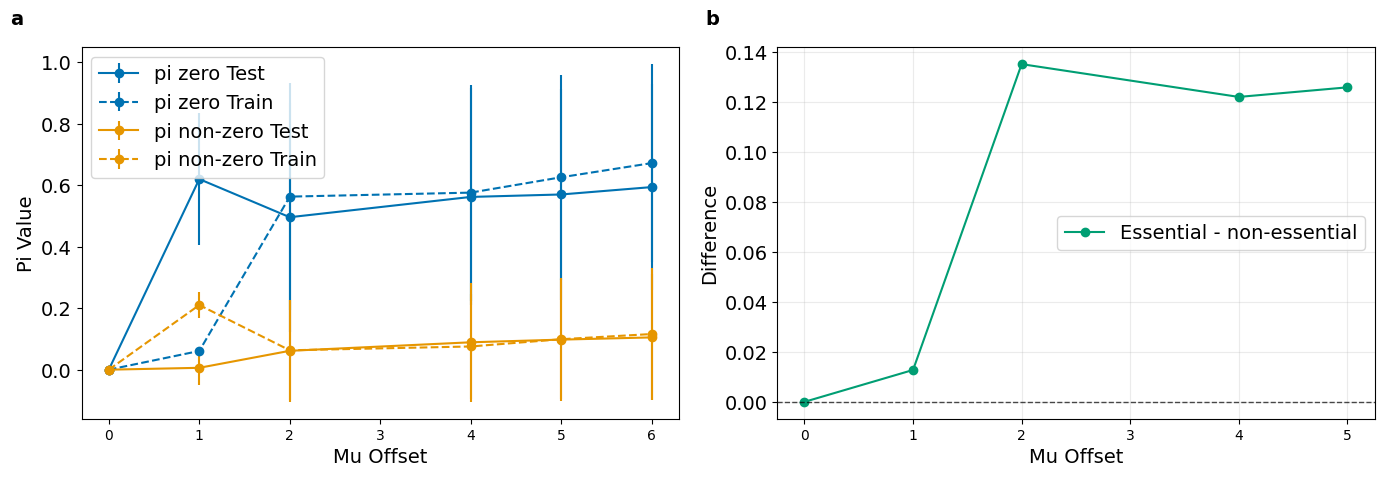

In [2]:
from Utils.plot_config import setup_plot_style, COLORS
import matplotlib.pyplot as plt
import pandas as pd

setup_plot_style()

mu_offset = [0, 1, 2, 4, 5, 6]
# pi values for test set at different offset levels
pi_zeros = [0, 0.62, 0.496, 0.562, 0.570, 0.594]
pi_non_zeros = [0, 0.0061, 0.0614, 0.0891, 0.0978, 0.105]
pi_zeros_sd = [0, 0.214, 0.372, 0.353, 0.342, 0.334]
pi_non_zeros_sd = [0, 0.057, 0.166, 0.193, 0.199, 0.205]

# pi values for train set at different offset levels
pi_zeros_train = [0, 0.0609, 0.563, 0.576, 0.626, 0.672]
pi_non_zeros_train = [0, 0.2103, 0.0631, 0.0755, 0.0991, 0.116]
pi_zeros_sd_train = [0.0015, 0.0044, 0.369, 0.351, 0.334, 0.322]
pi_non_zeros_sd_train = [0, 0.0434, 0.162, 0.171, 0.196, 0.214]

# Load essential vs non-essential pi differences per mu offset
PI_DIFF_FILE = "AE/results/pi_analysis/all_sets_mu_offset_diff.csv"
pi_diff_df = pd.read_csv(PI_DIFF_FILE)

required_cols = {"mu_offset_value", "difference"}
missing_cols = required_cols - set(pi_diff_df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in {PI_DIFF_FILE}: {sorted(missing_cols)}")

if "split" in pi_diff_df.columns:
    pi_diff_df = pi_diff_df[pi_diff_df["split"] == "all_sets"].copy()

pi_diff_df = pi_diff_df.sort_values("mu_offset_value")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

c_pi0, c_pi1 = COLORS["blue"], COLORS["orange"]
c_diff = COLORS["green"]

# Left panel: pi values vs mu offset (test/train)
axs[0].errorbar(
    mu_offset,
    pi_zeros,
    yerr=pi_zeros_sd,
    marker="o",
    linestyle="-",
    color=c_pi0,
    label="pi zero Test",
)
axs[0].errorbar(
    mu_offset,
    pi_zeros_train,
    yerr=pi_zeros_sd_train,
    marker="o",
    linestyle="--",
    color=c_pi0,
    label="pi zero Train",
)
axs[0].errorbar(
    mu_offset,
    pi_non_zeros,
    yerr=pi_non_zeros_sd,
    marker="o",
    linestyle="-",
    color=c_pi1,
    label="pi non-zero Test",
)
axs[0].errorbar(
    mu_offset,
    pi_non_zeros_train,
    yerr=pi_non_zeros_sd_train,
    marker="o",
    linestyle="--",
    color=c_pi1,
    label="pi non-zero Train",
)
# axs[0].set_title("Pi")
axs[0].set_xlabel("Mu Offset")
axs[0].set_ylabel("Pi Value")
axs[0].legend()

# Right panel: difference (essential - non-essential) vs mu offset from CSV
axs[1].plot(
    pi_diff_df["mu_offset_value"],
    pi_diff_df["difference"],
    marker="o",
    linestyle="-",
    color=c_diff,
    label="Essential - non-essential",
)
axs[1].axhline(0.0, color=COLORS["black"], linestyle="--", linewidth=1.0, alpha=0.7)
# axs[1].set_title("Difference by Mu Offset")
axs[1].set_xlabel("Mu Offset")
axs[1].set_ylabel("Difference")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

# Panel labels outside top-left corner of each subplots
axs[0].text(-0.12, 1.05, "a", transform=axs[0].transAxes, ha="left", va="bottom", fontweight="bold", clip_on=False)
axs[1].text(-0.12, 1.05, "b", transform=axs[1].transAxes, ha="left", va="bottom", fontweight="bold", clip_on=False)

plt.tight_layout()
plt.show()

/var/folders/nd/jwrydhcj1q9fy32wp8xg1c6h0000gn/T/ipykernel_12790/259480585.py:72: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


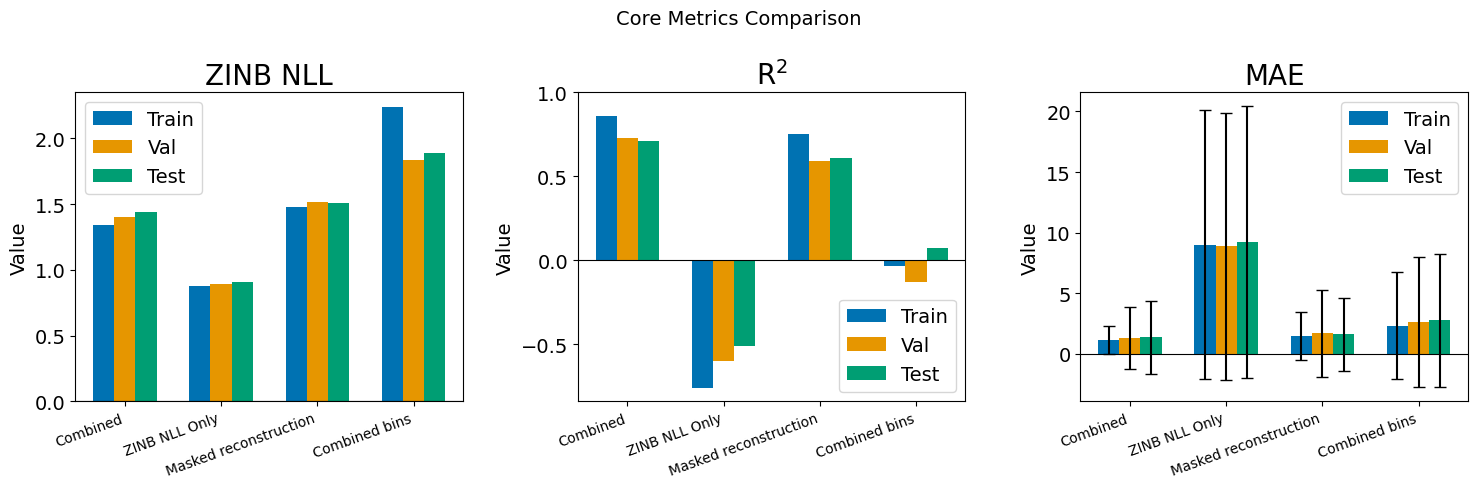

/var/folders/nd/jwrydhcj1q9fy32wp8xg1c6h0000gn/T/ipykernel_12790/259480585.py:72: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


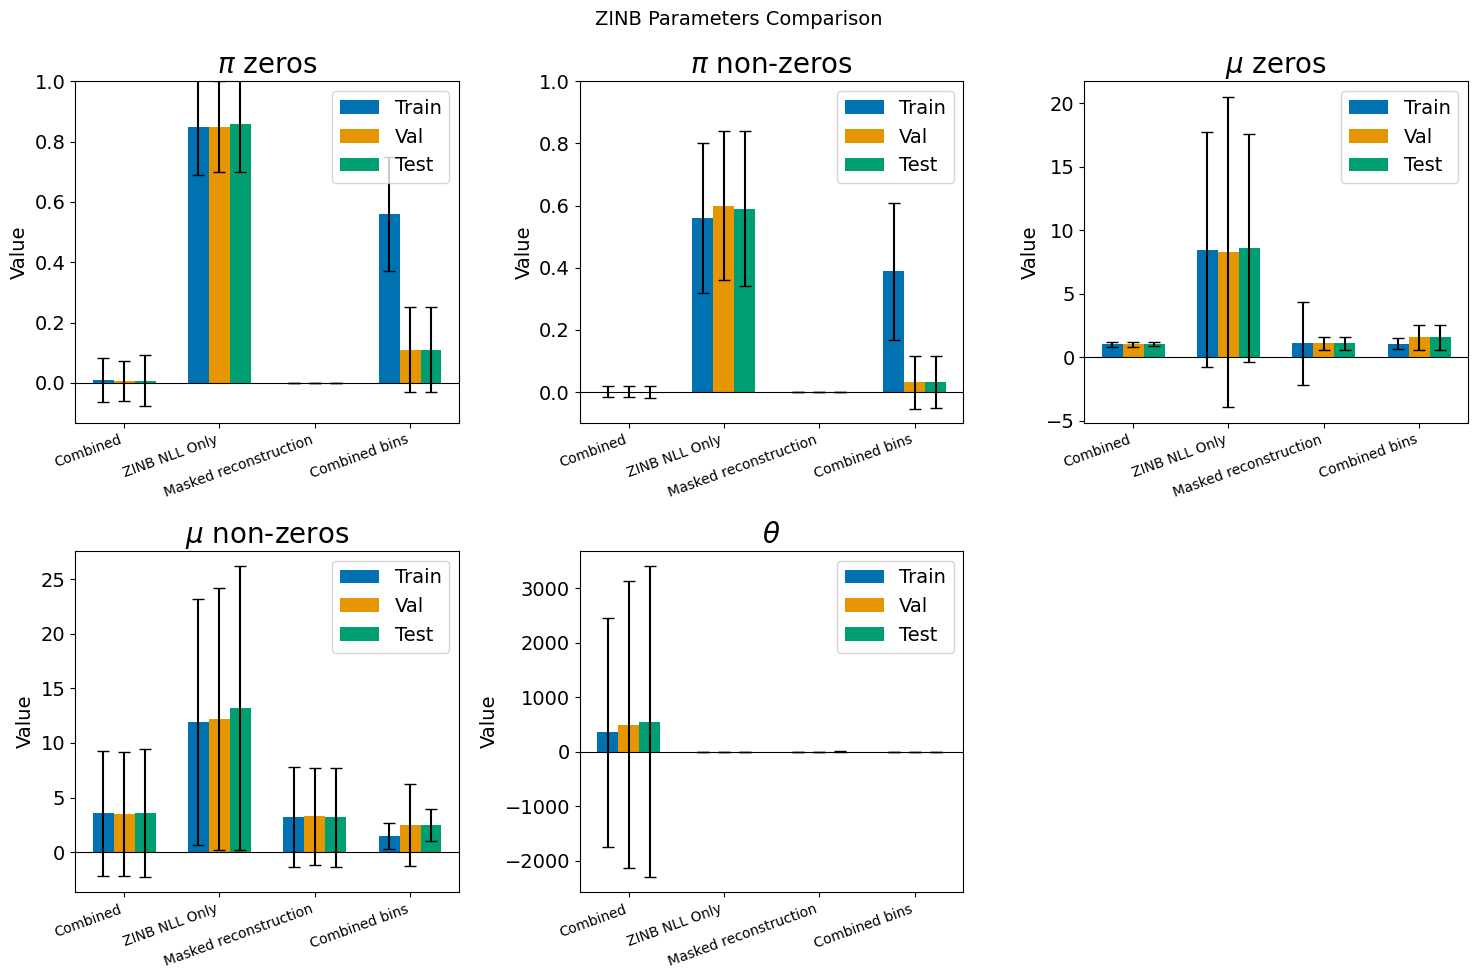

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from Utils.plot_config import setup_plot_style, COLORS

setup_plot_style()

def plot_grouped_bars(metrics_dict, model_names, split_names, errors_dict=None, fig_title=""):
    metric_names = list(metrics_dict.keys())
    n_metrics = len(metric_names)

    # Create grid layout: 2 rows if more than 3 metrics, otherwise 1 row
    if n_metrics <= 3:
        nrows, ncols = 1, n_metrics
    else:
        nrows = 2
        ncols = int(np.ceil(n_metrics / 2))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).flatten()

    x = np.arange(len(model_names))
    width = 0.22

    split_colors = {
        "Train": COLORS["blue"],
        "Val": COLORS["orange"],
        "Test": COLORS["green"],
    }

    for ax, metric in zip(axes, metric_names):
        for i, split in enumerate(split_names):
            values = metrics_dict[metric][split]
            offset = (i - 1) * width

            if errors_dict is not None and metric in errors_dict:
                errs = errors_dict[metric][split]
                ax.bar(
                    x + offset,
                    values,
                    width,
                    yerr=errs,
                    capsize=4,
                    label=split,
                    color=split_colors[split]
                )
            else:
                ax.bar(
                    x + offset,
                    values,
                    width,
                    label=split,
                    color=split_colors[split]
                )

        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=20, ha="right")
        ax.set_ylabel("Value")
        ax.axhline(0, linewidth=0.8, color="black")
        ax.legend()
        
        # Set y-axis limit for R² and pi metrics to go up to 1
        if "R$^2$" in metric or "$\\pi$" in metric or "pi" in metric.lower():
            current_ylim = ax.get_ylim()
            ax.set_ylim(current_ylim[0], 1.0)
    
    # Hide empty subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(fig_title, fontsize=14)
    plt.tight_layout()
    plt.show()

core_metrics = {
    "ZINB NLL": {
        "Train": [1.34, 0.878, 1.48, 2.24],
        "Val":   [1.40, 0.890, 1.52, 1.84],
        "Test":  [1.44, 0.910, 1.51, 1.89],
    },
    "R$^2$": {
        "Train": [0.86, -0.76, 0.75, -0.033],
        "Val":   [0.73, -0.60, 0.59, -0.13],
        "Test":  [0.71, -0.51, 0.61, 0.072],
    },
    "MAE": {
        "Train": [1.16, 9.00, 1.49, 2.32],
        "Val":   [1.29, 8.87, 1.70, 2.61],
        "Test":  [1.37, 9.23, 1.61, 2.76],
    }
}

core_errors = {
    "MAE": {
        "Train": [1.14, 11.1, 1.99, 4.40],
        "Val":   [2.55, 11.0, 3.61, 5.36],
        "Test":  [3.03, 11.2, 3.02, 5.51],
    }
}

# Table 2: ZINB parameters
param_metrics = {
    r"$\pi$ zeros": {
        "Train": [0.0078, 0.85, 0.0, 0.56],
        "Val":   [0.0069, 0.85, 0.0, 0.11],
        "Test":  [0.0072, 0.86, 0.0, 0.11],
    },
    r"$\pi$ non-zeros": {
        "Train": [0.0008, 0.56, 0.0, 0.389],
        "Val":   [0.0008, 0.60, 0.0, 0.031],
        "Test":  [0.0008, 0.59, 0.0, 0.032],
    },
    r"$\mu$ zeros": {
        "Train": [1.03, 8.48, 1.09, 1.07],
        "Val":   [1.03, 8.28, 1.09, 1.56],
        "Test":  [1.03, 8.60, 1.09, 1.57],
    },
    r"$\mu$ non-zeros": {
        "Train": [3.56, 11.93, 3.23, 1.49],
        "Val":   [3.48, 12.21, 3.26, 2.49],
        "Test":  [3.59, 13.18, 3.19, 2.45],
    },
    r"$\theta$": {
        "Train": [358, 1.00, 1.33, 1.0],
        "Val":   [500, 1.00, 1.35, 1.0],
        "Test":  [558, 1.00, 1.35, 1.0],
    }
}

param_errors = {
    r"$\pi$ zeros": {
        "Train": [0.073, 0.16, 0.0, 0.19],
        "Val":   [0.067, 0.15, 0.0, 0.14],
        "Test":  [0.085, 0.16, 0.0, 0.14],
    },
    r"$\pi$ non-zeros": {
        "Train": [0.018, 0.24, 0.0, 0.22],
        "Val":   [0.018, 0.24, 0.0, 0.085],
        "Test":  [0.019, 0.25, 0.0, 0.084],
    },
    r"$\mu$ zeros": {
        "Train": [0.18, 9.23, 3.23, 0.45],
        "Val":   [0.18, 12.21, 0.48, 0.95],
        "Test":  [0.177, 8.99, 0.48, 0.96],
    },
    r"$\mu$ non-zeros": {
        "Train": [5.75, 11.30, 4.58, 1.21],
        "Val":   [5.66, 12.03, 4.45, 3.74],
        "Test":  [5.86, 13.02, 4.53, 1.46],
    },
    r"$\theta$": {
        "Train": [2095, 0.001, 2.10, 0.0],
        "Val":   [2636, 0.014, 2.29, 0.0],
        "Test":  [2848, 0.017, 7.43, 0.0],
    }
}

# Define model names and split names
model_names = ["Combined", "ZINB NLL Only", "Masked reconstruction", "Combined bins"]
split_names = ["Train", "Val", "Test"]

# Plot core metrics
plot_grouped_bars(core_metrics, model_names, split_names, core_errors, "Core Metrics Comparison")

# Plot ZINB parameters
plot_grouped_bars(param_metrics, model_names, split_names, param_errors, "ZINB Parameters Comparison")


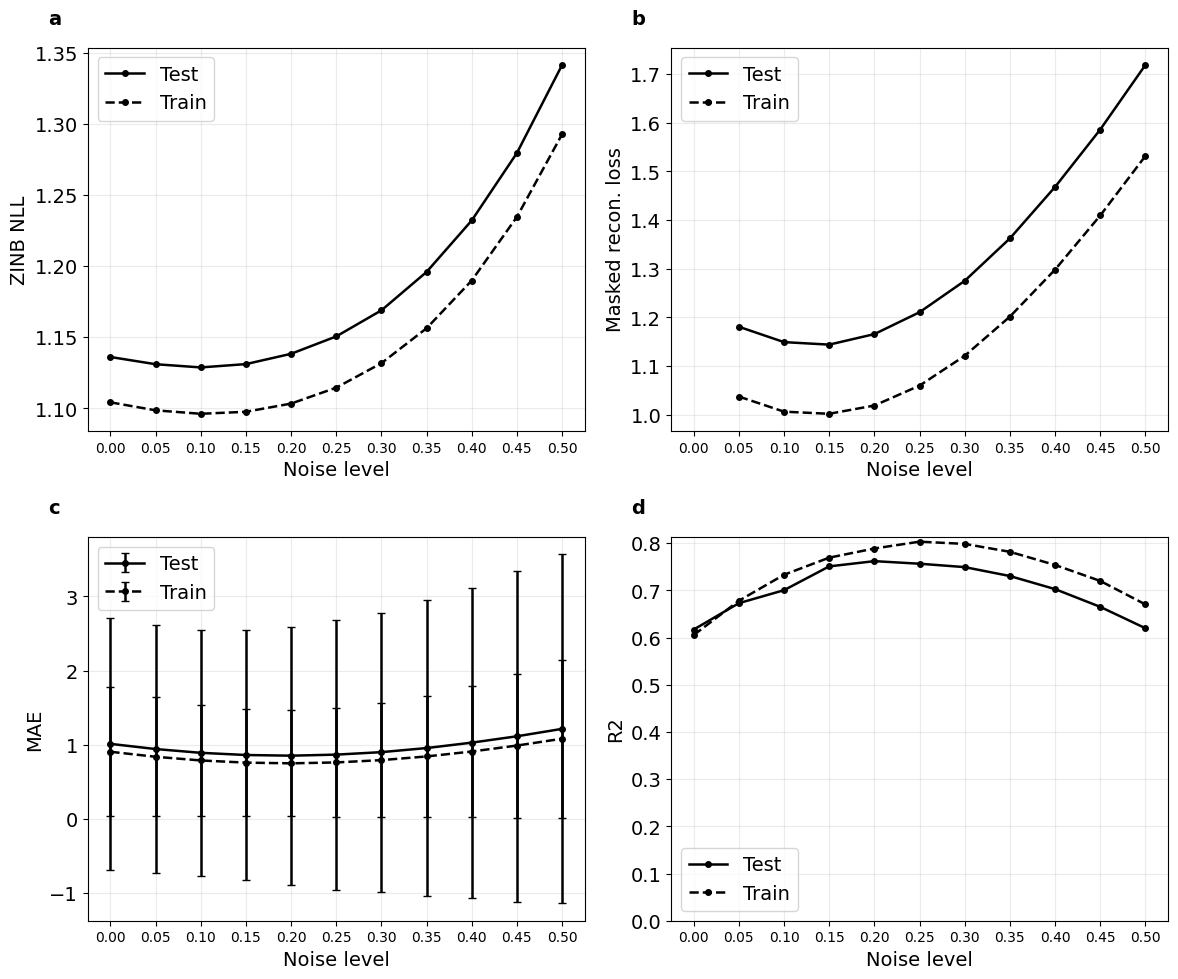

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from Utils.plot_config import setup_plot_style, COLORS

setup_plot_style()

RESULTS_PATH = "AE/results/noise_sweep_metrics.csv"
splits_to_plot = ["test", "train"]

results_df = pd.read_csv(RESULTS_PATH)

if "split" in results_df.columns:
    results_df = results_df[results_df["split"].isin(splits_to_plot)].copy()
else:
    raise ValueError(f"Missing 'split' column in {RESULTS_PATH}")

required_cols = ["eval_noise_level", "split", "zinb_nll", "masked_loss", "mae", "mae_sd", "r2"]
missing_cols = [col for col in required_cols if col not in results_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in {RESULTS_PATH}: {missing_cols}")

agg_df = (
    results_df.groupby(["split", "eval_noise_level"], as_index=False)[
        ["zinb_nll", "masked_loss", "mae", "mae_sd", "r2"]
    ]
    .mean()
    .sort_values(["split", "eval_noise_level"])
)

# Get shared x-ticks from all available noise levels
x_ticks = sorted(agg_df["eval_noise_level"].unique())

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axs.flatten()

plot_specs = [
    ("zinb_nll", "ZINB NLL"),
    ("masked_loss", "Masked recon. loss"),
    ("mae", "MAE"),
    ("r2", "R2"),
]

panel_labels = ["a", "b", "c", "d"]
line_styles = {"test": "-", "train": "--"}
line_labels = {"test": "Test", "train": "Train"}
line_color = COLORS["black"]

for ax, (metric, y_label), panel in zip(axes, plot_specs, panel_labels):
    for split in splits_to_plot:
        split_df = agg_df[agg_df["split"] == split]
        if split_df.empty:
            continue

        if metric == "mae":
            ax.errorbar(
                split_df["eval_noise_level"].values,
                split_df[metric].values,
                yerr=split_df["mae_sd"].values,
                fmt="o",
                linestyle=line_styles[split],
                color=line_color,
                linewidth=1.8,
                markersize=4,
                capsize=3,
                label=line_labels[split],
            )
        else:
            ax.plot(
                split_df["eval_noise_level"].values,
                split_df[metric].values,
                marker="o",
                linestyle=line_styles[split],
                color=line_color,
                linewidth=1.8,
                markersize=4,
                label=line_labels[split],
            )

    ax.set_ylabel(y_label)
    ax.set_xlabel("Noise level")
    ax.set_xticks(x_ticks)
    ax.tick_params(axis="x", labelbottom=True)  # show x tick labels on all subplots
    ax.grid(True, alpha=0.25)
    ax.text(
        -0.08, 1.05, panel,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
        clip_on=False
    )
    ax.legend()

    if metric == "r2":
        ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [ ]:
from Utils.plot_config import setup_plot_style, COLORS

setup_plot_style()
noise_levels = [0.10, 0.25, 0.5, 0.75, 0.9]
# Metrics different noise levels test